# Load and prepare the data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from google.colab import files
uploaded = files.upload()

Saving league-chemp.xlsx to league-chemp (1).xlsx


In [9]:
df = pd.read_excel('league-chemp.xlsx')

In [10]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   number   20 non-null     int64  
 1   team     20 non-null     object 
 2   matches  20 non-null     int64  
 3   wins     20 non-null     int64  
 4   draws    20 non-null     int64  
 5   loses    20 non-null     int64  
 6   goals    20 non-null     int64  
 7   ga       20 non-null     int64  
 8   points   20 non-null     int64  
 9   xG       20 non-null     float64
 10  xGA      20 non-null     float64
 11  xPTS     20 non-null     float64
dtypes: float64(3), int64(8), object(1)
memory usage: 2.0+ KB


,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS
0,1,Arsenal,36,24,7,5,68,26,79,72.35,31.93,74.71
1,2,Manchester City,36,23,8,5,75,32,77,76.71,42.34,72.24
2,3,Manchester United,36,18,11,7,63,48,65,65.57,47.73,59.24
3,4,Liverpool,36,17,8,11,60,48,59,62.71,49.88,58.50
4,5,Aston Villa,36,17,8,11,50,46,59,51.24,53.75,46.85


In [11]:
df = df.rename(columns={
    "number": "position",
    "matches": "matches_played",
    "loses": "losses",
    "goals": "goals_scored",
    "ga": "goals_conceded",
    "xG": "expected_goals",
    "xGA": "expected_goals_against",
    "xPTS": "expected_points"
})

# Which teams are performing better or worse than their underlying performance suggests?

In [12]:
df["performance_gap"] = df["points"] - df["expected_points"]

In [13]:
df.head()

,position,team,matches_played,wins,draws,losses,goals_scored,goals_conceded,points,expected_goals,expected_goals_against,expected_points,performance_gap
0,1,Arsenal,36,24,7,5,68,26,79,72.35,31.93,74.71,4.29
1,2,Manchester City,36,23,8,5,75,32,77,76.71,42.34,72.24,4.76
2,3,Manchester United,36,18,11,7,63,48,65,65.57,47.73,59.24,5.76
3,4,Liverpool,36,17,8,11,60,48,59,62.71,49.88,58.50,0.50
4,5,Aston Villa,36,17,8,11,50,46,59,51.24,53.75,46.85,12.15


# Rank teams by over/underperformance

In [14]:
overperformers = df.sort_values("performance_gap", ascending=False)
underperformers = df.sort_values("performance_gap", ascending=True)

In [18]:
overperformers.head(10)

,position,team,matches_played,wins,draws,losses,goals_scored,goals_conceded,points,expected_goals,expected_goals_against,expected_points,performance_gap
4,5,Aston Villa,36,17,8,11,50,46,59,51.24,53.75,46.85,12.15
11,12,Sunderland,36,12,12,12,37,46,48,39.52,58.09,38.36,9.64
10,11,Fulham,36,14,6,16,44,50,48,46.37,59.10,41.18,6.82
2,3,Manchester United,36,18,11,7,63,48,65,65.57,47.73,59.24,5.76
1,2,Manchester City,36,23,8,5,75,32,77,76.71,42.34,72.24,4.76
9,10,Everton,36,13,10,13,46,46,49,48.28,57.31,44.45,4.55
0,1,Arsenal,36,24,7,5,68,26,79,72.35,31.93,74.71,4.29
15,16,Nottingham Forest,36,11,10,15,45,47,43,45.03,59.12,40.05,2.95
3,4,Liverpool,36,17,8,11,60,48,59,62.71,49.88,58.50,0.50
6,7,Brighton,36,14,11,11,52,42,53,55.48,50.67,52.65,0.35


In [19]:
underperformers.head(10)

,position,team,matches_played,wins,draws,losses,goals_scored,goals_conceded,points,expected_goals,expected_goals_against,expected_points,performance_gap
19,20,Wolverhampton Wanderers,36,3,9,24,25,66,18,34.10,65.54,31.66,-13.66
13,14,Leeds,36,10,14,12,48,53,44,57.07,51.36,55.21,-11.21
8,9,Chelsea,36,13,10,13,55,49,49,70.20,53.63,57.84,-8.84
14,15,Crystal Palace,36,11,11,14,38,47,44,59.63,54.59,52.16,-8.16
16,17,Tottenham,36,9,11,16,46,55,38,43.24,54.23,44.56,-6.56
12,13,Newcastle United,36,13,7,16,50,52,46,58.24,54.63,52.31,-6.31
17,18,West Ham,36,9,9,18,42,62,36,45.95,64.03,41.03,-5.03
7,8,Brentford,36,14,9,13,52,49,51,63.25,54.29,55.60,-4.60
5,6,Bournemouth,36,13,16,7,56,52,55,63.78,53.44,57.76,-2.76
18,19,Burnley,36,4,9,23,37,73,21,35.46,78.51,23.48,-2.48


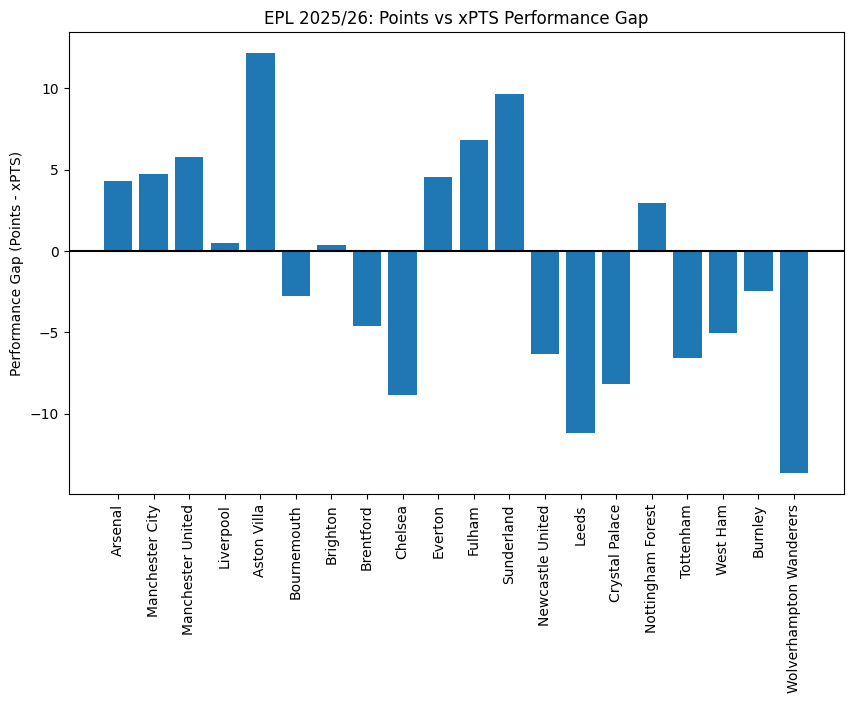

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(df["team"], df["performance_gap"])
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.title("EPL 2025/26: Points vs xPTS Performance Gap")
plt.ylabel("Performance Gap (Points - xPTS)")
plt.show()

# Key Insight
The EPL 2025/26 table shows significant divergence between actual points and expected points, with teams like Chelsea and Wolves underperforming their underlying metrics, while Aston Villa and Sunderland overperform. This suggests strong volatility in match outcome efficiency across the league

# Question 2
Which teams are most efficient in converting xG into actual goals?

In [20]:
df["finishing_efficiency"] = df["goals_scored"] / df["expected_goals"]

In [21]:
df.sort_values("finishing_efficiency", ascending=False)[
    ["team", "goals_scored", "expected_goals", "finishing_efficiency"]
]

,team,goals_scored,expected_goals,finishing_efficiency
16,Tottenham,46,43.24,1.063830
18,Burnley,37,35.46,1.043429
15,Nottingham Forest,45,45.03,0.999334
1,Manchester City,75,76.71,0.977708
4,Aston Villa,50,51.24,0.975800
2,Manchester United,63,65.57,0.960805
3,Liverpool,60,62.71,0.956785
9,Everton,46,48.28,0.952775
10,Fulham,44,46.37,0.948889
0,Arsenal,68,72.35,0.939876


# Key Insight
Tottenham are the most efficient attacking team in the EPL 2025/26 season, slightly overperforming their expected goals. In contrast, Chelsea and Crystal Palace show significant attacking inefficiency, converting far fewer chances than expected, indicating potential structural or finishing quality issues in their attacking systems.

# Question 3
Which teams are defensively efficient (GA vs xGA)?

In [22]:
df["defensive_efficiency"] = df["goals_conceded"] / df["expected_goals_against"]

In [23]:
df.sort_values("defensive_efficiency")[[
    "team", "goals_conceded", "expected_goals_against", "defensive_efficiency"
]]

,team,goals_conceded,expected_goals_against,defensive_efficiency
1,Manchester City,32,42.34,0.755786
11,Sunderland,46,58.09,0.791875
15,Nottingham Forest,47,59.12,0.794993
9,Everton,46,57.31,0.802652
0,Arsenal,26,31.93,0.814281
6,Brighton,42,50.67,0.828893
10,Fulham,50,59.10,0.846024
4,Aston Villa,46,53.75,0.855814
14,Crystal Palace,47,54.59,0.860964
7,Brentford,49,54.29,0.902560


# Key Insight
Manchester City and Arsenal lead the Premier League in defensive efficiency, conceding significantly fewer goals than expected based on xGA. Sunderland and Nottingham Forest emerge as surprising overperformers, suggesting strong defensive organization relative to squad expectations. In contrast, Leeds and Tottenham show defensive inefficiencies, while Chelsea’s struggles are not defensive but primarily attacking in nature.

In [24]:
import pandas as pd

df["attack_strength"] = df["expected_goals"]
df["defense_weakness"] = df["expected_goals_against"]

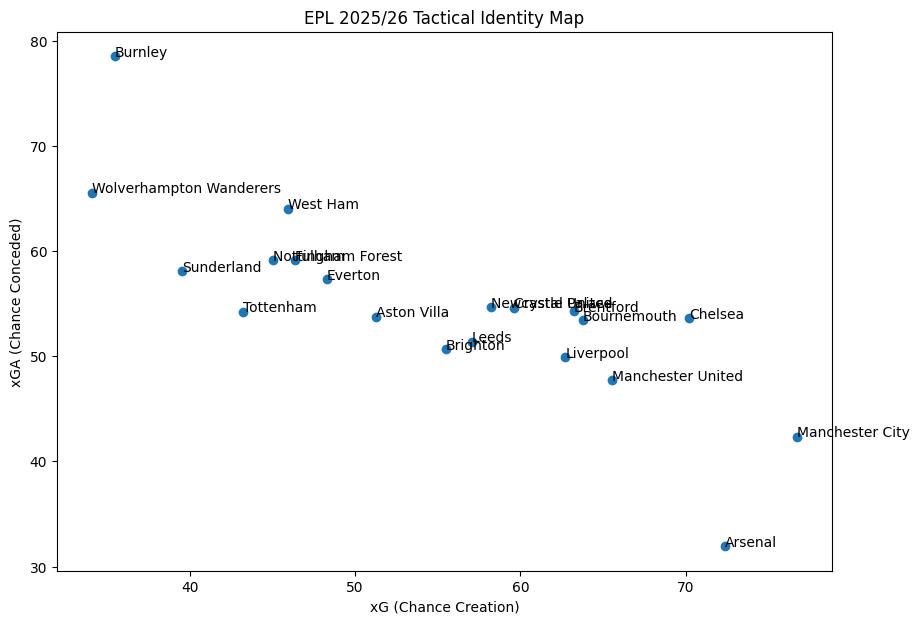

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(df["expected_goals"], df["expected_goals_against"])

for i in range(len(df)):
    plt.text(df["expected_goals"][i], df["expected_goals_against"][i], df["team"][i])

plt.xlabel("xG (Chance Creation)")
plt.ylabel("xGA (Chance Conceded)")
plt.title("EPL 2025/26 Tactical Identity Map")

plt.show()

# Question 4
Does attacking quality (xG) actually translate into league success (points)?

In [26]:
df["expected_goals"] = df["expected_goals"]  # already exists

correlation = df["expected_goals"].corr(df["points"])
print(correlation)

0.8209809605969516


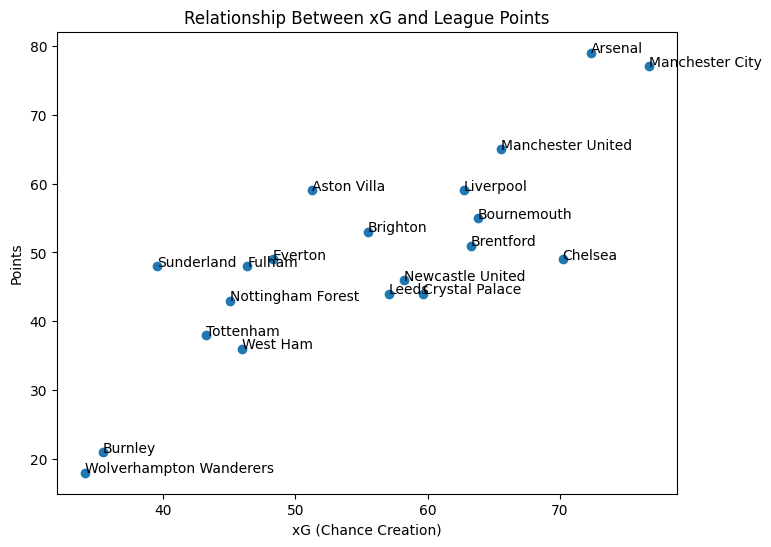

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["expected_goals"], df["points"])

for i in range(len(df)):
    plt.text(df["expected_goals"][i], df["points"][i], df["team"][i])

plt.xlabel("xG (Chance Creation)")
plt.ylabel("Points")
plt.title("Relationship Between xG and League Points")
plt.show()

# Key Insight
The scatter plot shows a strong positive relationship (r ≈ 0.82) between xG and points, confirming that chance creation is a key driver of league success. However, notable deviations such as Chelsea (high xG, low points) and Sunderland (low xG, high points) highlight the impact of finishing efficiency, defensive stability, and match-level variance.

# Question 5
Which teams are truly “balanced” in attack, defense, and efficiency?

Arsenal
High xG (~72)
Very low xGA (~31)
Small performance gap (~+4.3)

👉 Meaning:

Strong attack
Elite defense
Stable results

✔️ Identity:

Complete title-winning structure

🔥 Manchester City
Highest xG (~76)
Strong xGA (~42)
Small gap (~+4.7)

👉 Meaning:

Balanced dominance
Elite chance creation + elite control

✔️ Identity:

Most complete team in league

🧠 Liverpool
Strong xG (~62)
Stable xGA (~50)
Near-neutral efficiency

👉 Meaning:

Balanced but slightly less dominant than top 2

✔️ Identity:

Strong top-tier system, slightly inconsistent defensively

🟡 VERY STRONG BUT NOT PERFECTLY BALANCED
⚡ Manchester United
Good xG (~65)
Average xGA (~47)
Slight overperformance (~+5.7)

👉 Meaning:

Attack-driven success
Defense not elite but stable
⚡ Aston Villa
Mid-high xG (~51)
Mid xGA (~53)
Strong overperformance (+12.15)

👉 Meaning:

Results stronger than performance suggests
Efficiency-driven team
⚡ Brighton
Balanced xG/xGA (~55 / ~50)
Almost zero gap

👉 Meaning:

Systemically stable mid-table elite model
🟠 MID-LEVEL BALANCED TEAMS
Brentford
Fulham
Everton
Newcastle

👉 Profile:

Moderate attack
Moderate defense
Slight inefficiencies

✔️ Identity:

“Competitive but not elite systems”

🔴 UNBALANCED / PROBLEM TEAMS
⚠️ Chelsea
High xG (~70)
Medium xGA (~53)
Large negative finishing efficiency

👉 Key insight:

Attack elite creation, but wasteful finishing = imbalance

⚠️ Tottenham
Medium xG (~43)
Medium xGA (~54)
Slight inefficiency

👉 Meaning:

Neither attack nor defense elite
Relies on moments, not structure
🚨 Wolves
Low xG (~34)
High xGA (~65)

👉 Meaning:

Structural weakness on both ends

✔️ Identity:

Relegation profile team

🚨 Leeds / Burnley
Low attack + weak defense (especially Leeds xGA inefficiency)

👉 Meaning:

Systemic imbalance
📊 FINAL INSIGHT (WHAT THIS ALL MEANS)
🏆 ELITE BALANCED TEAMS
Arsenal
Manchester City

👉 Key trait:

High creation + low concession + stable efficiency

⚙️ SYSTEM STABLE TEAMS
Liverpool
Brighton
Manchester United

👉 Key trait:

Solid but not perfect across all metrics

⚡ OVER/UNDER-DEPENDENT TEAMS
Aston Villa (results overperformance)
Chelsea (chance creation but poor finishing)
Sunderland (results overperformance)
🚨 STRUCTURALLY WEAK TEAMS
Wolves
Leeds
Burnley

👉 Key trait:

Poor attack + poor defense = instability

# SUMMARY
The EPL 2025/26 season reveals a clear hierarchy of team balance. Arsenal and Manchester City are the only fully balanced elite teams, combining high chance creation, strong defensive control, and stable efficiency. Liverpool and Manchester United form a strong secondary tier, while teams like Chelsea show structural imbalance driven by attacking inefficiency. At the bottom, Wolves and Leeds exhibit systemic weaknesses in both attack and defense.